# 2025-11-23 Credit Card Fraud Detection

This notebook demonstrates data engineering, model training, and metric evaluation for credit card fraud detection using the Hugging Face dataset `liberatoratif/Credit-card-fraud-detection`.

- Focus: Fraud detection (imbalanced classification)
- Dataset: liberatoratif/Credit-card-fraud-detection (Hugging Face Datasets)
- Metrics: Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix
- Language: English & Korean comments for habit

---

## 1. Import Libraries & Set Up

필수 라이브러리와 환경을 준비합니다. (Hugging Face Datasets, scikit-learn, pandas, numpy 등)

In [8]:
# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# 한글 폰트 설정 (Korean font for matplotlib)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## 2. Load Dataset from Hugging Face

Hugging Face Datasets 라이브러리로 신용카드 사기 데이터셋을 불러옵니다.

In [9]:
# 데이터셋 로드 (pandas로 직접 다운로드)
# liberatoratif/Credit-card-fraud-detection
app_url = 'https://huggingface.co/datasets/liberatoratif/Credit-card-fraud-detection/resolve/main/application_record.csv'
credit_url = 'https://huggingface.co/datasets/liberatoratif/Credit-card-fraud-detection/resolve/main/credit_record.csv'

app_df = pd.read_csv(app_url)
credit_df = pd.read_csv(credit_url)

print('application_record.csv columns:', app_df.columns.tolist())
print('credit_record.csv columns:', credit_df.columns.tolist())

app_df.head(), credit_df.head()

application_record.csv columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']
credit_record.csv columns: ['ID', 'MONTHS_BALANCE', 'STATUS']


(        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
 0  5008804           M            Y               Y             0   
 1  5008805           M            Y               Y             0   
 2  5008806           M            Y               Y             0   
 3  5008808           F            N               Y             0   
 4  5008809           F            N               Y             0   
 
    AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
 0          427500.0               Working               Higher education   
 1          427500.0               Working               Higher education   
 2          112500.0               Working  Secondary / secondary special   
 3          270000.0  Commercial associate  Secondary / secondary special   
 4          270000.0  Commercial associate  Secondary / secondary special   
 
      NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
 0        Civil marriage   Rented apartm

## 3. Data Exploration & Preprocessing

데이터 분포, 결측치, 클래스 불균형 등 탐색 및 전처리 수행

[INFO] Loaded model_df from local cache: model_df.parquet
Shape: (36457, 19)
Columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'Class']
Class distribution:
Class
0    35841
1      616
Name: count, dtype: int64


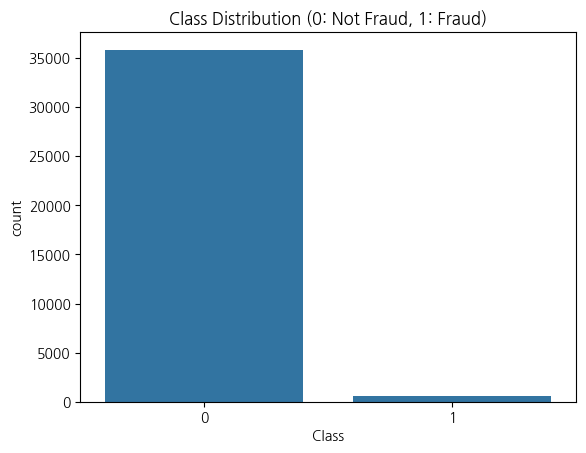

Missing values: 11323


In [10]:
# 데이터 탐색 (최종 모델링 테이블 사용, 완전 자동/무중단 버전)
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

LOCAL_PATH = 'model_df.parquet'

# 1. 캐시 파일이 있으면 바로 로드
if os.path.exists(LOCAL_PATH):
    model_df = pd.read_parquet(LOCAL_PATH)
    print(f"[INFO] Loaded model_df from local cache: {LOCAL_PATH}")
else:
    # 2. 없으면 원본 데이터 다운로드 및 처리
    print("[INFO] Downloading and processing raw data from Hugging Face...")
    app_url = 'https://huggingface.co/datasets/liberatoratif/Credit-card-fraud-detection/resolve/main/application_record.csv'
    credit_url = 'https://huggingface.co/datasets/liberatoratif/Credit-card-fraud-detection/resolve/main/credit_record.csv'
    app_df = pd.read_csv(app_url)
    credit_df = pd.read_csv(credit_url)
    fraud_statuses = {'2', '3', '4', '5'}
    credit_df['is_fraud'] = credit_df['STATUS'].astype(str).isin(fraud_statuses)
    fraud_label = credit_df.groupby('ID')['is_fraud'].max().astype(int).reset_index().rename(columns={'is_fraud': 'Class'})
    model_df = app_df.merge(fraud_label, on='ID', how='inner')
    model_df.to_parquet(LOCAL_PATH)
    print(f"[INFO] Saved model_df to local cache: {LOCAL_PATH}")

# 탐색 코드 (항상 동작)
print('Shape:', model_df.shape)
print('Columns:', model_df.columns.tolist())
print('Class distribution:')
print(model_df['Class'].value_counts())
sns.countplot(x='Class', data=model_df)
plt.title('Class Distribution (0: Not Fraud, 1: Fraud)')
plt.show()
print('Missing values:', model_df.isnull().sum().sum())

In [13]:
# 데이터 분할 및 스케일링 (model_df를 항상 사용, 자동 인코딩 및 ID 제거 포함)
# 1. ID 컬럼 제거 (식별자)
if 'ID' in model_df.columns:
    model_df = model_df.drop('ID', axis=1)
# 2. 모든 범주형(문자형) 변수 원-핫 인코딩 (Class 제외)
cat_cols = model_df.drop('Class', axis=1).select_dtypes(include=['object', 'category']).columns
model_df_encoded = pd.get_dummies(model_df, columns=cat_cols)
X = model_df_encoded.drop('Class', axis=1)
y = model_df_encoded['Class']

# 3. 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (29165, 54)
X_test_scaled shape: (7292, 54)


## 4. Train Baseline Model (Logistic Regression)

로지스틱 회귀로 베이스라인 모델을 학습합니다.

In [14]:
# 로지스틱 회귀 모델 학습
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

## 5. Evaluate Model Performance

정확도, 정밀도, 재현율, F1, ROC-AUC, 혼동 행렬 등 주요 지표로 평가합니다.

Accuracy: 0.6131
Precision: 0.0213
Recall: 0.4878
F1 Score: 0.0408
ROC-AUC: 0.5564


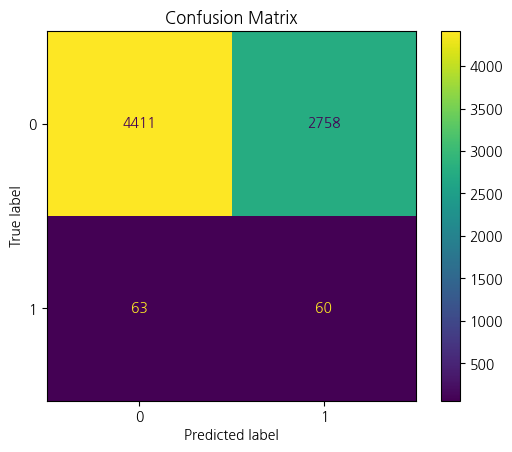

In [15]:
# 평가 지표 계산
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc:.4f}")

ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

## 6. Cost-based Evaluation of Model Performance

모델의 예측 결과에 따른 실제 비용(비용 구조)을 계산합니다.

- False Positive (FP): 정상 거래를 사기로 잘못 예측 (예: 불필요한 조사 비용)
- False Negative (FN): 사기 거래를 정상으로 놓침 (예: 사기 피해 비용)

비용 구조를 정의하고, 혼동 행렬을 기반으로 총 비용을 계산합니다.

In [16]:
# 비용 구조 정의 (예시)
cost_fp = 10   # False Positive 1건당 비용 (예: 10달러)
cost_fn = 500  # False Negative 1건당 비용 (예: 500달러)

# 혼동 행렬에서 FP, FN 추출
fp = cm[0,1]
fn = cm[1,0]

total_cost = fp * cost_fp + fn * cost_fn
print(f"False Positives (FP): {fp} (Cost: ${fp * cost_fp})")
print(f"False Negatives (FN): {fn} (Cost: ${fn * cost_fn})")
print(f"Total Cost: ${total_cost}")

False Positives (FP): 2758 (Cost: $27580)
False Negatives (FN): 63 (Cost: $31500)
Total Cost: $59080


In [17]:
# 데이터셋 컬럼 구조 미리 확인 (샘플 5개만 다운로드)
from datasets import load_dataset
sample = load_dataset('liberatoratif/Credit-card-fraud-detection', split='train[:5]')
df_sample = pd.DataFrame(sample)
print('Columns:', df_sample.columns.tolist())
df_sample.head()

C:\Users\hsyyu\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'xxhash'

## [IMPORTANT] Dataset Structure Issue & Solution

The Hugging Face dataset contains multiple CSV files with different schemas (e.g., `application_record.csv` and `credit_record.csv`).

- `application_record.csv`: Contains features for each customer (demographics, income, etc.)
- `credit_record.csv`: Contains time-series credit status for each customer

To proceed, we will:
1. Download both files separately using pandas.
2. Join/aggregate them to create a single modeling table for fraud detection.

---

In [18]:
# 1. Download the two CSVs directly from Hugging Face repo
import pandas as pd

app_url = 'https://huggingface.co/datasets/liberatoratif/Credit-card-fraud-detection/resolve/main/application_record.csv'
credit_url = 'https://huggingface.co/datasets/liberatoratif/Credit-card-fraud-detection/resolve/main/credit_record.csv'

app_df = pd.read_csv(app_url)
credit_df = pd.read_csv(credit_url)

print('application_record.csv columns:', app_df.columns.tolist())
print('credit_record.csv columns:', credit_df.columns.tolist())

app_df.head(), credit_df.head()

application_record.csv columns: ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']
credit_record.csv columns: ['ID', 'MONTHS_BALANCE', 'STATUS']


(        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
 0  5008804           M            Y               Y             0   
 1  5008805           M            Y               Y             0   
 2  5008806           M            Y               Y             0   
 3  5008808           F            N               Y             0   
 4  5008809           F            N               Y             0   
 
    AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
 0          427500.0               Working               Higher education   
 1          427500.0               Working               Higher education   
 2          112500.0               Working  Secondary / secondary special   
 3          270000.0  Commercial associate  Secondary / secondary special   
 4          270000.0  Commercial associate  Secondary / secondary special   
 
      NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
 0        Civil marriage   Rented apartm

## 2. Label Construction for Fraud Detection

- We will define a customer as 'fraudulent' if their credit record ever shows a status of '2' (past due for 60+ days) or worse.
- This is a common proxy for default/fraud in credit datasets.
- We will aggregate `credit_record.csv` to create a binary label for each customer (ID).

---

In [20]:
# 2. Create binary label for each customer
# STATUS: '2' or worse (2, 3, 4, 5) means serious delinquency
fraud_statuses = {'2', '3', '4', '5'}
credit_df['is_fraud'] = credit_df['STATUS'].astype(str).isin(fraud_statuses)

# Aggregate: if any record for a customer is fraud, label as 1
fraud_label = credit_df.groupby('ID')['is_fraud'].max().astype(int).reset_index().rename(columns={'is_fraud': 'Class'})

# Merge with application data
model_df = app_df.merge(fraud_label, on='ID', how='inner')
print('Final modeling table shape:', model_df.shape)
model_df['Class'].value_counts()

Final modeling table shape: (36457, 19)


Class
0    35841
1      616
Name: count, dtype: int64